In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

## The Trapezoidal Rule (composite trapezoidal rule)

In [247]:
def composite_trapezoidal_rule(t, f):
    integral = np.zeros(len(f))

    for i in range(1, len(f)):
        h = t[i] - t[i-1]
        integral[i] = (integral[i-1] + (f[i-1] + f[i]) * h/2)

    return integral

# Vehicle1

In [248]:
df = pd.read_excel("dev2_combined_365bags_2025-02-23_07-10-45_2025-02-23_13-15-31_CET.xlsx")

In [249]:
data = df[["timestamp (1740291045,1740312931) [unix]","velocity (0,200) [km/h]", "velocity_heading (0,360) [掳]"]].copy()

Each dataset consists of 4 Special stages. By looking at the dataset, I was able to pinpoint row number (start and end) of each Special stage. 

In [250]:
data["SS"] = "" 

In [251]:
data.loc[65499:67978, "SS"] = "SS1"
data.loc[69685:73097, "SS"] = "SS2"
data.loc[190521:194040, "SS"] = "SS3"
data.loc[198312:200644, "SS"] = "SS4"

In [252]:
ss1 = data[data["SS"] == "SS1"].copy()
ss2 = data[data["SS"] == "SS2"].copy()
ss3 = data[data["SS"] == "SS3"].copy()
ss4 = data[data["SS"] == "SS4"].copy()

In [253]:
ss1[[
    "timestamp (1740291045,1740312931) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]",
    "SS"
]].head(10)

,"timestamp (1740291045,1740312931) [unix]","velocity (0,200) [km/h]","velocity_heading (0,360) [掳]",SS
65499,1.740298e+09,22.04,310.4,SS1
65500,1.740298e+09,22.78,308.3,SS1
65501,1.740298e+09,24.08,306.5,SS1
65502,1.740298e+09,24.45,309.3,SS1
65503,1.740298e+09,25.93,310.8,SS1
65504,1.740298e+09,25.37,308.1,SS1
65505,1.740298e+09,25.37,308.9,SS1
65506,1.740298e+09,25.19,310.9,SS1
65507,1.740298e+09,28.71,310.7,SS1
65508,1.740298e+09,30.93,309.8,SS1


## Special Stage 1

### Timestamp

In [254]:
ss1["dt"] = ss1["timestamp (1740291045,1740312931) [unix]"].diff()   # t_i = t_i+1 - t_i

In [255]:
#print(ss1["dt"].describe())
#print(ss1["dt"].value_counts().sort_index())

### Checking missing values

In [256]:
"""
print(ss1[[    # checking for nul values.... 1 in velocity , 1 in velocity heading
    "timestamp (1740291045,1740312931) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss1[[    # checking for nul values.... 1 in velocity , 1 in velocity heading\n    "timestamp (1740291045,1740312931) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [257]:
ss1["velocity (0,200) [km/h]"] = ss1["velocity (0,200) [km/h]"].interpolate()
ss1["velocity_heading (0,360) [掳]"] = ss1["velocity_heading (0,360) [掳]"].interpolate()

C:\Users\karla\AppData\Local\Temp\ipykernel_460\2692293008.py:1: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  ss1["velocity (0,200) [km/h]"] = ss1["velocity (0,200) [km/h]"].interpolate()


### Velocity (km/h to m/s)

In [258]:
ss1["velocity (0,200) [km/h]"] = pd.to_numeric(ss1["velocity (0,200) [km/h]"], errors = "coerce") # original velocity from dataset is type object

In [259]:
ss1["velocity [m/s]"] = ss1["velocity (0,200) [km/h]"] / 3.6 

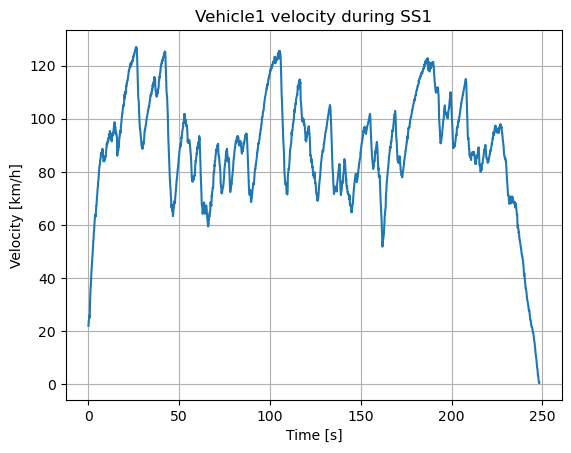

In [260]:
ss1["time_rel"] = ss1["timestamp (1740291045,1740312931) [unix]"] - ss1["timestamp (1740291045,1740312931) [unix]"].iloc[0]
plt.figure()
plt.plot(ss1["time_rel"], ss1["velocity (0,200) [km/h]"])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Vehicle1 velocity during SS1")
plt.grid()
plt.show()

### Velocity heading (degrees to radians)

In [261]:
ss1["velocity_heading (rad)"] = ss1["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [262]:
psi = ss1["velocity_heading (rad)"]

In [263]:
ss1["v_x"] = ss1["velocity [m/s]"] * np.sin(psi)
ss1["v_y"] = ss1["velocity [m/s]"] * np.cos(psi)

In [264]:
t = ss1["timestamp (1740291045,1740312931) [unix]"].to_numpy()

ss1["x"] = composite_trapezoidal_rule(t, ss1["v_x"].to_numpy())
ss1["y"] = composite_trapezoidal_rule(t, ss1["v_y"].to_numpy())

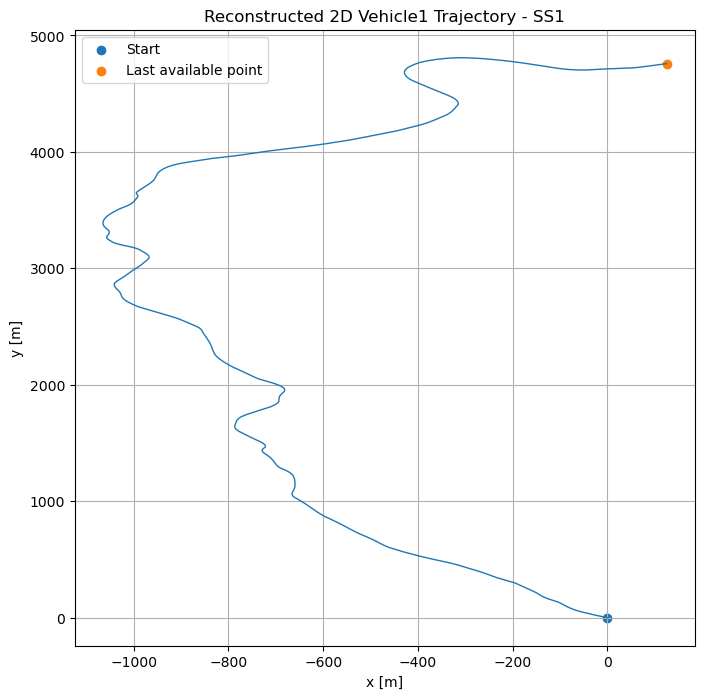

In [265]:
plt.figure(figsize=(8,8))
plt.plot(ss1["x"], ss1["y"], linewidth = 1)

plt.scatter(ss1["x"].iloc[0], ss1["y"].iloc[0], marker = "o", label = "Start")
last_valid = ss1[["x", "y"]].dropna().iloc[-1]
plt.scatter(last_valid["x"], last_valid["y"], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS1")
plt.grid()
plt.legend()

plt.show()

In [266]:
dx = ss1["x"].diff()
dy = ss1["y"].diff()
ss1["ds"] = np.sqrt(dx**2 + dy**2)

trajectory_length = ss1["ds"].sum()
print(f"Reconstructed trajectory length: {trajectory_length:.2f} m")

Reconstructed trajectory length: 6098.84 m


In [267]:
valid = ss1[["timestamp (1740291045,1740312931) [unix]", "velocity [m/s]"]].dropna()
t = valid["timestamp (1740291045,1740312931) [unix]"].to_numpy()
v = valid["velocity [m/s]"].to_numpy()

distance = composite_trapezoidal_rule(t, v)[-1]
 
print(f"Distance obtained from velocity integration: {distance:.2f} m")

Distance obtained from velocity integration: 6099.13 m


In [268]:
trajectory_ss1 = ss1[["timestamp (1740291045,1740312931) [unix]", "x", "y"]].copy()

In [269]:
trajectory_ss1.to_csv("vehicle1_SS1_trajectory.csv", index=False)

## Special Stage 2

In [270]:
ss2["dt"] = ss2["timestamp (1740291045,1740312931) [unix]"].diff()
ss2["velocity (0,200) [km/h]"] = pd.to_numeric(ss2["velocity (0,200) [km/h]"], errors = "coerce")

In [271]:
#print(ss2["dt"].describe())
#print(ss2["dt"].value_counts().sort_index())

In [272]:
# 3 velocity and 4 velocity heading

print(ss2[[    # checking for nul values
    "timestamp (1740291045,1740312931) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())


timestamp (1740291045,1740312931) [unix]    0
velocity (0,200) [km/h]                     3
velocity_heading (0,360) [掳]                4
dtype: int64


In [273]:
ss2["time_rel"] = ss2["timestamp (1740291045,1740312931) [unix]"] - ss2["timestamp (1740291045,1740312931) [unix]"].iloc[0]

### Interpolation

In [274]:
def interpolation(y_before, y_after, x_position, x_before, x_after):
    return ((y_after - y_before) * (x_position - x_before))/(x_after - x_before) + y_before

In [275]:
nan_index_veloHeading = ss2[ss2["velocity_heading (0,360) [掳]"].isna()].index
print(nan_index_veloHeading)
print(ss2.loc[72365:72370,["time_rel", "velocity_heading (0,360) [掳]"]])

Index([72368, 73095, 73096, 73097], dtype='int64')
       time_rel  velocity_heading (0,360) [掳]
72365     268.0                         251.9
72366     268.1                         251.6
72367     268.2                         251.7
72368     268.3                           NaN
72369     268.4                         250.7
72370     268.5                         250.6


In [276]:
v_before = ss2.loc[72367, "velocity_heading (0,360) [掳]"]
v_after = ss2.loc[72369, "velocity_heading (0,360) [掳]"]
x_position = ss2.loc[72368, "time_rel"]
x_before = ss2.loc[72367, "time_rel"]
x_after = ss2.loc[72369, "time_rel"]

result = interpolation(v_before, v_after, x_position, x_before, x_after)
print(result)

251.2


In [277]:
ss2["velocity (0,200) [km/h]"] = ss2["velocity (0,200) [km/h]"].interpolate() # because there was a missing value that disabled the reconstruction of trajectoy to be full
ss2["velocity_heading (0,360) [掳]"] = ss2["velocity_heading (0,360) [掳]"].interpolate()

print(ss2.loc[72365:72370, "velocity_heading (0,360) [掳]"])

72365    251.9
72366    251.6
72367    251.7
72368    251.2
72369    250.7
72370    250.6
Name: velocity_heading (0,360) [掳], dtype: float64


In [278]:
ss2["velocity [m/s]"] = ss2["velocity (0,200) [km/h]"] / 3.6 

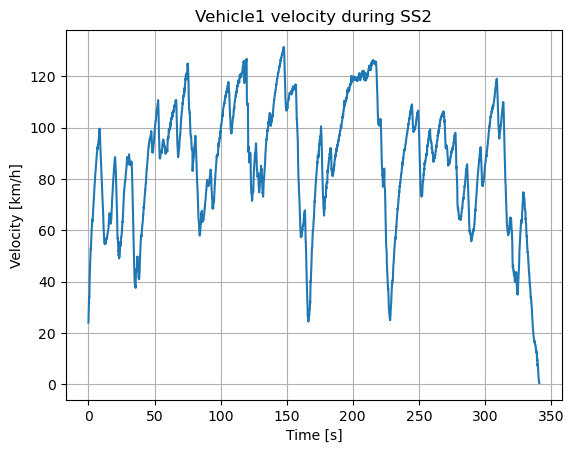

In [279]:
plt.figure()
plt.plot(ss2["time_rel"], ss2["velocity (0,200) [km/h]"])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Vehicle1 velocity during SS2")
plt.grid()
plt.show()

In [280]:
ss2["velocity_heading (rad)"] = ss2["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [281]:
psi_2 = ss2["velocity_heading (rad)"]
ss2["v_x"] = ss2["velocity [m/s]"] * np.sin(psi_2)
ss2["v_y"] = ss2["velocity [m/s]"] * np.cos(psi_2)

In [282]:
t_2 = ss2["timestamp (1740291045,1740312931) [unix]"].to_numpy()

ss2["x"] = composite_trapezoidal_rule(t_2, ss2["v_x"].to_numpy())
ss2["y"] = composite_trapezoidal_rule(t_2, ss2["v_y"].to_numpy())

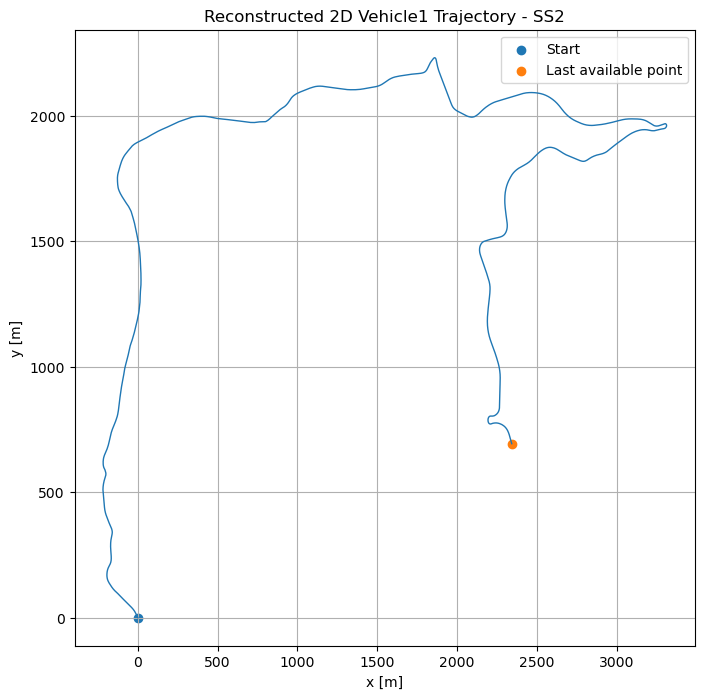

In [283]:
plt.figure(figsize=(8,8))
plt.plot(ss2["x"], ss2["y"], linewidth = 1)

plt.scatter(ss2["x"].iloc[0], ss2["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss2["x"].iloc[-1], ss2["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS2")
plt.grid()
plt.legend()

plt.show()

In [284]:
dx_2 = ss2["x"].diff()
dy_2 = ss2["y"].diff()
ss2["ds"] = np.sqrt(dx_2**2 + dy_2**2)

trajectory_length_2 = ss2["ds"].sum()
print(f"Reconstructed trajectory length: {trajectory_length_2:.2f} m")

Reconstructed trajectory length: 8174.54 m


In [285]:
t_2 = ss2["timestamp (1740291045,1740312931) [unix]"].to_numpy()
v_2 = ss2["velocity [m/s]"].to_numpy()

distance_2 = composite_trapezoidal_rule(t_2, v_2)[-1]
 
print(f"Distance obtained from velocity integration: {distance_2:.2f} m")

Distance obtained from velocity integration: 8175.05 m


## Special Stage 3

In [286]:
ss3["dt"] = ss3["timestamp (1740291045,1740312931) [unix]"].diff()
ss3["velocity (0,200) [km/h]"] = pd.to_numeric(ss3["velocity (0,200) [km/h]"], errors = "coerce")

In [287]:
#print(ss3["dt"].describe())
#print(ss3["dt"].value_counts().sort_index())

In [288]:
"""
print(ss3[[    # checking for nul values   (4 velocity heading. 3 velocity)  so interpolation needed 
    "timestamp (1740291045,1740312931) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss3[[    # checking for nul values   (4 velocity heading. 3 velocity)  so interpolation needed \n    "timestamp (1740291045,1740312931) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [289]:
ss3["velocity (0,200) [km/h]"] = ss3["velocity (0,200) [km/h]"].interpolate()
ss3["velocity_heading (0,360) [掳]"] = ss3["velocity_heading (0,360) [掳]"].interpolate()

In [290]:
ss3["velocity [m/s]"] = ss3["velocity (0,200) [km/h]"] / 3.6 

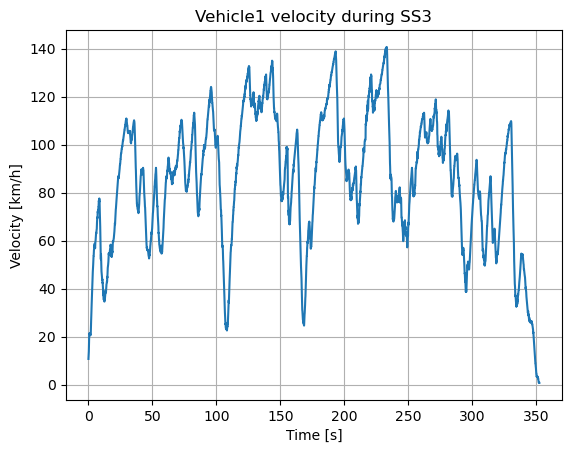

In [291]:
ss3["time_rel"] = ss3["timestamp (1740291045,1740312931) [unix]"] - ss3["timestamp (1740291045,1740312931) [unix]"].iloc[0]
plt.figure()
plt.plot(ss3["time_rel"], ss3["velocity (0,200) [km/h]"])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Vehicle1 velocity during SS3")
plt.grid()
plt.show()

In [292]:
ss3["velocity_heading (rad)"] = ss3["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [293]:
psi_3 = ss3["velocity_heading (rad)"]
ss3["v_x"] = ss3["velocity [m/s]"] * np.sin(psi_3)
ss3["v_y"] = ss3["velocity [m/s]"] * np.cos(psi_3)

In [294]:
t_3 = ss3["timestamp (1740291045,1740312931) [unix]"].to_numpy()

ss3["x"] = composite_trapezoidal_rule(t_3, ss3["v_x"].to_numpy())
ss3["y"] = composite_trapezoidal_rule(t_3, ss3["v_y"].to_numpy())

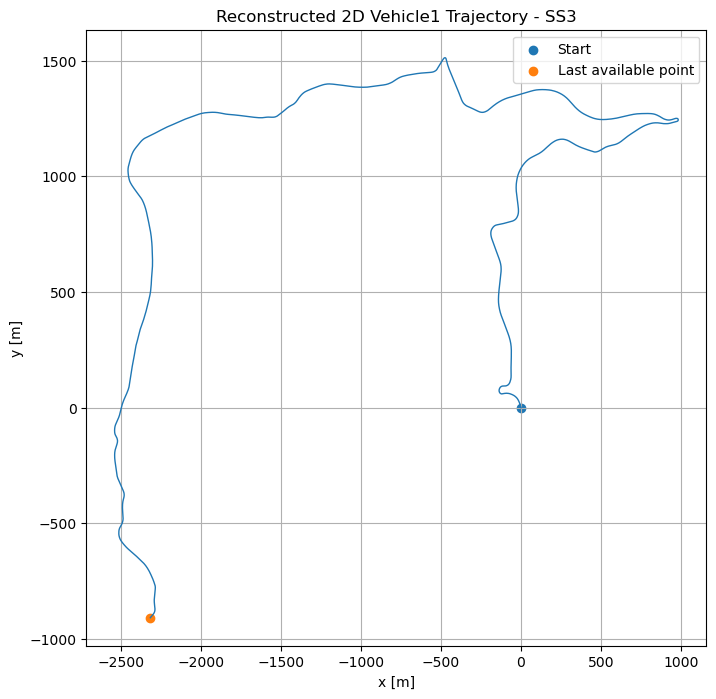

In [295]:
plt.figure(figsize=(8,8))
plt.plot(ss3["x"], ss3["y"], linewidth = 1)

plt.scatter(ss3["x"].iloc[0], ss3["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss3["x"].iloc[-1], ss3["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS3")
plt.grid()
plt.legend()

plt.show()

In [296]:
dx_3 = ss3["x"].diff()
dy_3 = ss3["y"].diff()
ss3["ds"] = np.sqrt(dx_3**2 + dy_3**2)

trajectory_length_3 = ss3["ds"].sum()
print(f"Reconstructed trajectory length: {trajectory_length_3:.2f} m")

Reconstructed trajectory length: 8350.79 m


In [297]:
t_3 = ss3["timestamp (1740291045,1740312931) [unix]"].to_numpy()
v_3 = ss3["velocity [m/s]"].to_numpy()

distance_3 = composite_trapezoidal_rule(t_3, v_3)[-1]
 
print(f"Distance obtained from velocity integration: {distance_3:.2f} m")

Distance obtained from velocity integration: 8351.23 m


## Special Stage 4

In [298]:
ss4["dt"] = ss4["timestamp (1740291045,1740312931) [unix]"].diff()
ss4["velocity (0,200) [km/h]"] = pd.to_numeric(ss4["velocity (0,200) [km/h]"], errors = "coerce")

In [299]:
#print(ss4["dt"].describe())
#print(ss4["dt"].value_counts().sort_index())

In [300]:
# 3 velocity, 3 velocity heading
"""
print(ss4[[    
    "timestamp (1740291045,1740312931) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss4[[    \n    "timestamp (1740291045,1740312931) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [301]:
ss4["velocity (0,200) [km/h]"] = ss4["velocity (0,200) [km/h]"].interpolate()
ss4["velocity_heading (0,360) [掳]"] = ss4["velocity_heading (0,360) [掳]"].interpolate()

In [302]:
ss4["velocity [m/s]"] = ss4["velocity (0,200) [km/h]"] / 3.6 

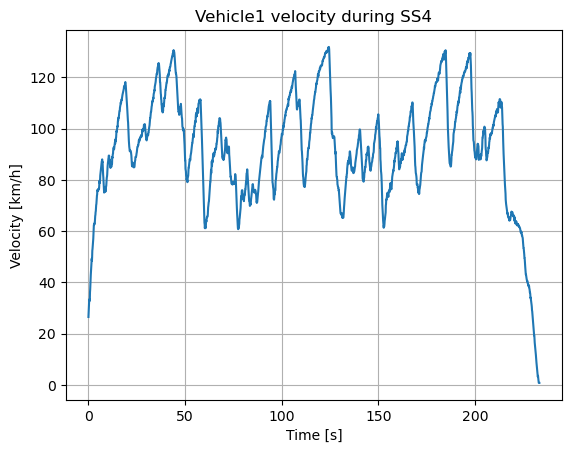

In [303]:
ss4["time_rel"] = ss4["timestamp (1740291045,1740312931) [unix]"] - ss4["timestamp (1740291045,1740312931) [unix]"].iloc[0]
plt.figure()
plt.plot(ss4["time_rel"], ss4["velocity (0,200) [km/h]"])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Vehicle1 velocity during SS4")
plt.grid()
plt.show()

In [304]:
ss4["velocity_heading (rad)"] = ss4["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [305]:
psi_4 = ss4["velocity_heading (rad)"]
ss4["v_x"] = ss4["velocity [m/s]"] * np.sin(psi_4)
ss4["v_y"] = ss4["velocity [m/s]"] * np.cos(psi_4)

In [306]:
t_4 = ss4["timestamp (1740291045,1740312931) [unix]"].to_numpy()

ss4["x"] = composite_trapezoidal_rule(t_4, ss4["v_x"].to_numpy())
ss4["y"] = composite_trapezoidal_rule(t_4, ss4["v_y"].to_numpy())

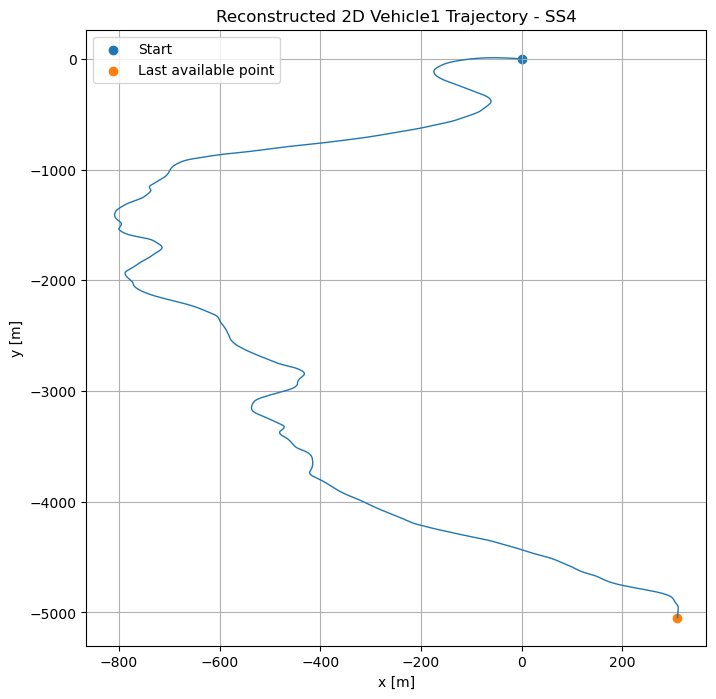

In [307]:
plt.figure(figsize=(8,8))
plt.plot(ss4["x"], ss4["y"], linewidth = 1)

plt.scatter(ss4["x"].iloc[0], ss4["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss4["x"].iloc[-1], ss4["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS4")
plt.grid()
plt.legend()

plt.show()

In [308]:
dx_4 = ss4["x"].diff()
dy_4 = ss4["y"].diff()
ss4["ds"] = np.sqrt(dx_4**2 + dy_4**2)

trajectory_length_4 = ss4["ds"].sum()
print(f"Reconstructed trajectory length: {trajectory_length_4:.2f} m")

Reconstructed trajectory length: 5954.04 m


In [309]:
t_4 = ss4["timestamp (1740291045,1740312931) [unix]"].to_numpy()
v_4 = ss4["velocity [m/s]"].to_numpy()

distance_4 = composite_trapezoidal_rule(t_4, v_4)[-1]
 
print(f"Distance obtained from velocity integration: {distance_4:.2f} m")

Distance obtained from velocity integration: 5954.26 m


# Trajectory analysis of Vehicle1, Vehicle2 and Vehicle3 on SS3

### Vehicle2 (SS3)

In [310]:
df_2 = pd.read_excel("dev_3_combined_447bags_2025-02-23_07-06-09_2025-02-23_14-32-35_CET.xlsx")

In [311]:
data_2 = df_2[["timestamp (1740290769,1740317555) [unix]","velocity (0,200) [km/h]", "velocity_heading (0,360) [掳]"]].copy()

In [312]:
ss3_v2 = data_2.loc[167378:170629].copy()

In [313]:
ss3_v2["dt"] = ss3_v2["timestamp (1740290769,1740317555) [unix]"].diff()

In [314]:
#print(ss3_v2["dt"].describe())
#print(ss3_v2["dt"].value_counts().sort_index())

In [315]:
ss3_v2["velocity (0,200) [km/h]"] = pd.to_numeric(ss3_v2["velocity (0,200) [km/h]"], errors = "coerce")

In [316]:
"""
print(ss3_v2[[    # no interpolation needed 
    "timestamp (1740290769,1740317555) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss3_v2[[    # no interpolation needed \n    "timestamp (1740290769,1740317555) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [317]:
ss3_v2["velocity [m/s]"] = ss3_v2["velocity (0,200) [km/h]"] / 3.6 

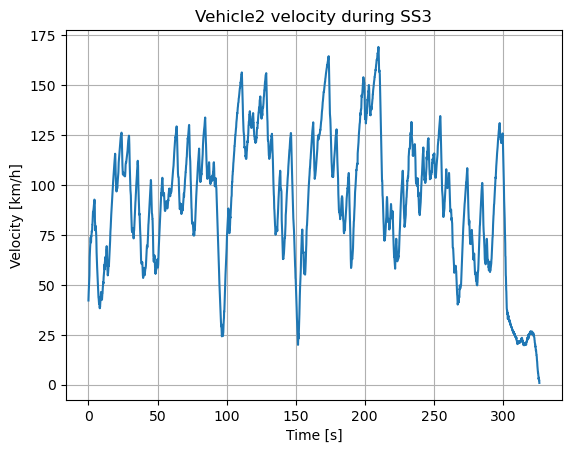

In [318]:
ss3_v2["time_rel"] = ss3_v2["timestamp (1740290769,1740317555) [unix]"] - ss3_v2["timestamp (1740290769,1740317555) [unix]"].iloc[0]
plt.figure()
plt.plot(ss3_v2["time_rel"], ss3_v2["velocity (0,200) [km/h]"])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Vehicle2 velocity during SS3")
plt.grid()
plt.show()

In [319]:
ss3_v2["velocity_heading (rad)"] = ss3_v2["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [320]:
psi_v2 = ss3_v2["velocity_heading (rad)"]
ss3_v2["v_x"] = ss3_v2["velocity [m/s]"] * np.sin(psi_v2)
ss3_v2["v_y"] = ss3_v2["velocity [m/s]"] * np.cos(psi_v2)

In [321]:
t_v2 = ss3_v2["timestamp (1740290769,1740317555) [unix]"].to_numpy()

ss3_v2["x"] = composite_trapezoidal_rule(t_v2, ss3_v2["v_x"].to_numpy())
ss3_v2["y"] = composite_trapezoidal_rule(t_v2, ss3_v2["v_y"].to_numpy())

### Vehicle3 (SS3)

In [322]:
df_3 = pd.read_excel("dev_4_3_combined_372bags_2025-02-23_08-28-03_2025-02-23_14-39-30_CET.xlsx")

In [323]:
data_3 = df_3[["timestamp (1740295683,1740317970) [unix]","velocity (0,200) [km/h]", "velocity_heading (0,360) [掳]"]].copy()

In [324]:
ss3_v3 = data_3.loc[124106:127277].copy()

In [325]:
ss3_v3["dt"] = ss3_v3["timestamp (1740295683,1740317970) [unix]"].diff()
ss3_v3["velocity (0,200) [km/h]"] = pd.to_numeric(ss3_v3["velocity (0,200) [km/h]"], errors = "coerce")

In [326]:
#print(ss3_v3["dt"].describe())
#print(ss3_v3["dt"].value_counts().sort_index())

In [327]:
"""
print(ss3_v2[[    # no interpolation needed 
    "timestamp (1740290769,1740317555) [unix]",
    "velocity (0,200) [km/h]",
    "velocity_heading (0,360) [掳]"
]].isna().sum())
"""

'\nprint(ss3_v2[[    # no interpolation needed \n    "timestamp (1740290769,1740317555) [unix]",\n    "velocity (0,200) [km/h]",\n    "velocity_heading (0,360) [掳]"\n]].isna().sum())\n'

In [328]:
ss3_v3["velocity [m/s]"] = ss3_v3["velocity (0,200) [km/h]"] / 3.6 

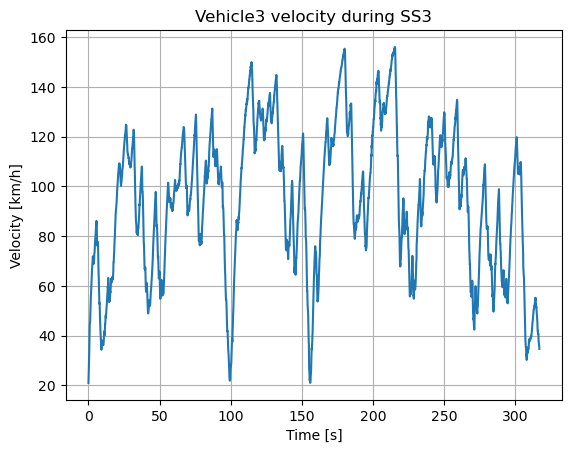

In [329]:
ss3_v3["time_rel"] = ss3_v3["timestamp (1740295683,1740317970) [unix]"] - ss3_v3["timestamp (1740295683,1740317970) [unix]"].iloc[0]
plt.figure()
plt.plot(ss3_v3["time_rel"], ss3_v3["velocity (0,200) [km/h]"])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Vehicle3 velocity during SS3")
plt.grid()
plt.show()

In [330]:
ss3_v3["velocity_heading (rad)"] = ss3_v3["velocity_heading (0,360) [掳]"] * (math.pi / 180)

In [331]:
psi_v3 = ss3_v3["velocity_heading (rad)"]
ss3_v3["v_x"] = ss3_v3["velocity [m/s]"] * np.sin(psi_v3)
ss3_v3["v_y"] = ss3_v3["velocity [m/s]"] * np.cos(psi_v3)

In [332]:
t_v3 = ss3_v3["timestamp (1740295683,1740317970) [unix]"].to_numpy()

ss3_v3["x"] = composite_trapezoidal_rule(t_v3, ss3_v3["v_x"].to_numpy())
ss3_v3["y"] = composite_trapezoidal_rule(t_v3, ss3_v3["v_y"].to_numpy())

### Velocity comparison

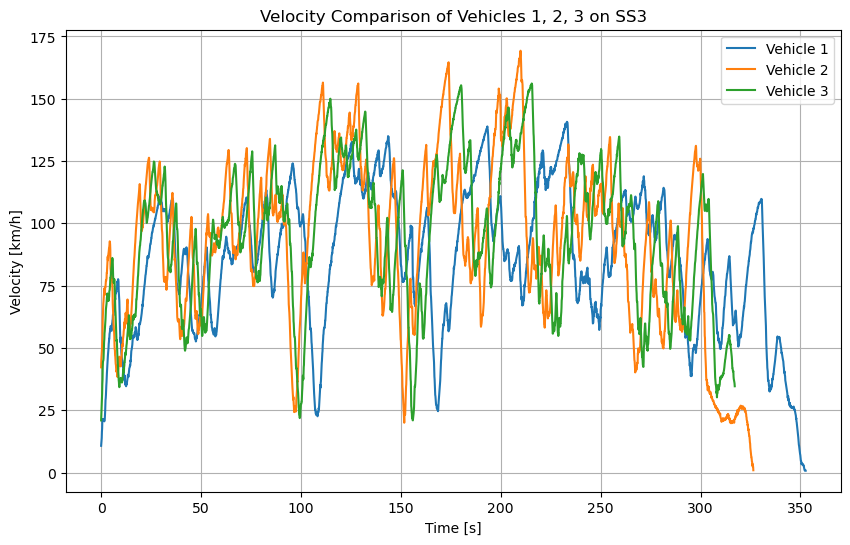

In [333]:
plt.figure(figsize=(10, 6))

plt.plot(ss3["time_rel"], ss3["velocity (0,200) [km/h]"], label="Vehicle 1")
plt.plot(ss3_v2["time_rel"], ss3_v2["velocity (0,200) [km/h]"], label="Vehicle 2")
plt.plot(ss3_v3["time_rel"], ss3_v3["velocity (0,200) [km/h]"], label="Vehicle 3")

plt.xlabel("Time [s]")
plt.ylabel("Velocity [km/h]")
plt.title("Velocity Comparison of Vehicles 1, 2, 3 on SS3")

plt.grid()
plt.legend()
plt.show()

### Trajectory comparison

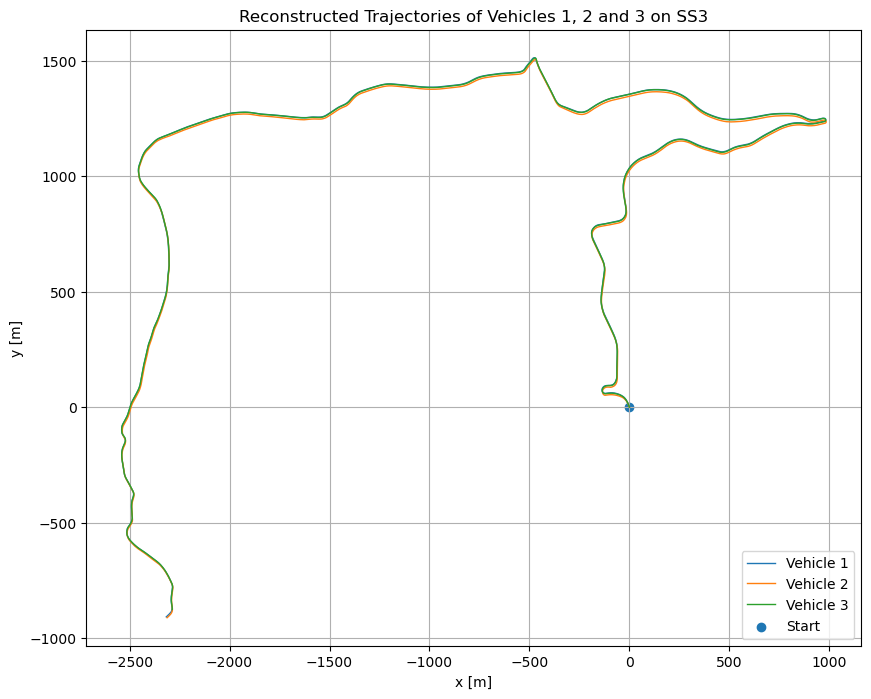

In [334]:
plt.figure(figsize=(10, 8))

plt.plot(ss3["x"], ss3["y"], linewidth=1, label="Vehicle 1")
plt.plot(ss3_v2["x"], ss3_v2["y"], linewidth=1, label="Vehicle 2")
plt.plot(ss3_v3["x"], ss3_v3["y"], linewidth=1, label="Vehicle 3")

plt.scatter(ss3["x"].iloc[0], ss3["y"].iloc[0], marker="o", label="Start")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Reconstructed Trajectories of Vehicles 1, 2 and 3 on SS3")

plt.grid()
plt.legend()
plt.show()

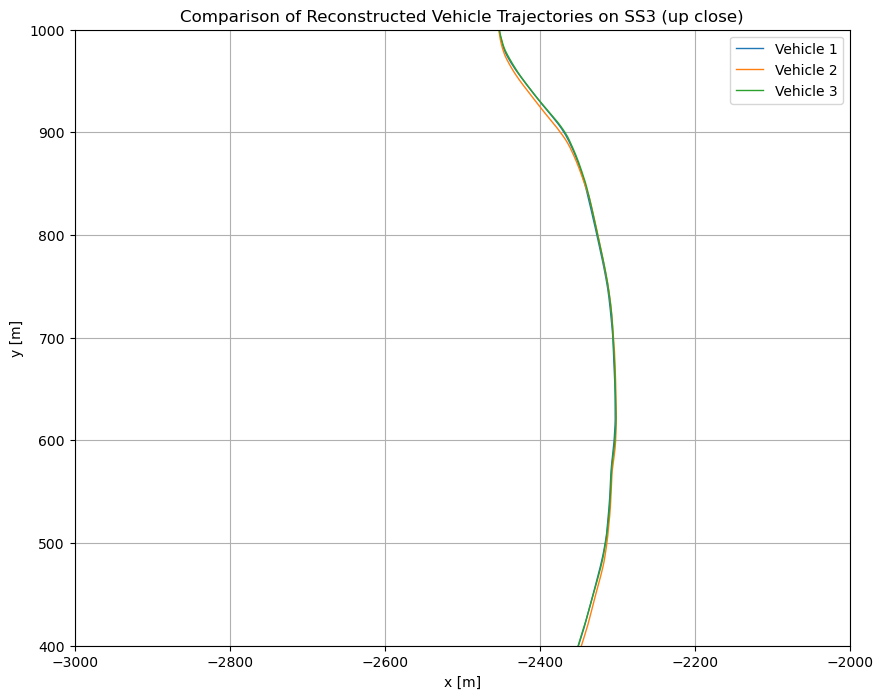

In [335]:
plt.figure(figsize=(10, 8))

plt.plot(ss3["x"], ss3["y"], linewidth=1, label="Vehicle 1")
plt.plot(ss3_v2["x"], ss3_v2["y"], linewidth=1, label="Vehicle 2")
plt.plot(ss3_v3["x"], ss3_v3["y"], linewidth=1, label="Vehicle 3")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Comparison of Reconstructed Vehicle Trajectories on SS3 (up close)")

plt.xlim(-3000, -2000)   
plt.ylim(400, 1000)  

plt.grid()
plt.legend()
plt.show()

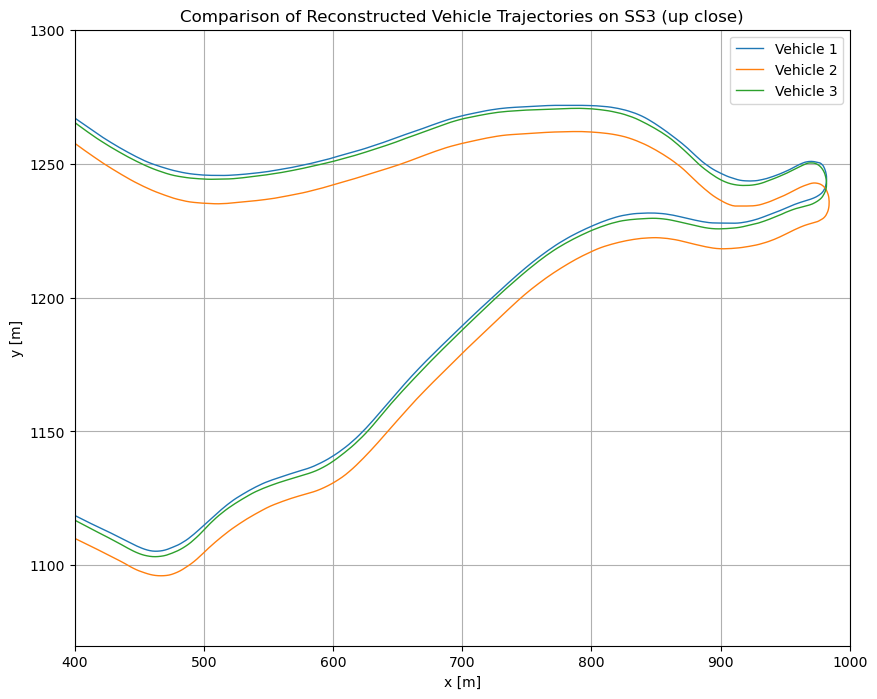

In [336]:
plt.figure(figsize=(10, 8))

plt.plot(ss3["x"], ss3["y"], linewidth=1, label="Vehicle 1")
plt.plot(ss3_v2["x"], ss3_v2["y"], linewidth=1, label="Vehicle 2")
plt.plot(ss3_v3["x"], ss3_v3["y"], linewidth=1, label="Vehicle 3")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Comparison of Reconstructed Vehicle Trajectories on SS3 (up close)")

plt.xlim(400, 1000)   
plt.ylim(1070, 1300)  

plt.grid()
plt.legend()
plt.show()

In [337]:
ss3.to_csv("ss3_reconstructed.csv", index=False)
ss3_v2.to_csv("ss3_v2_reconstructed.csv", index=False)
ss3_v3.to_csv("ss3_v3_reconstructed.csv", index=False)

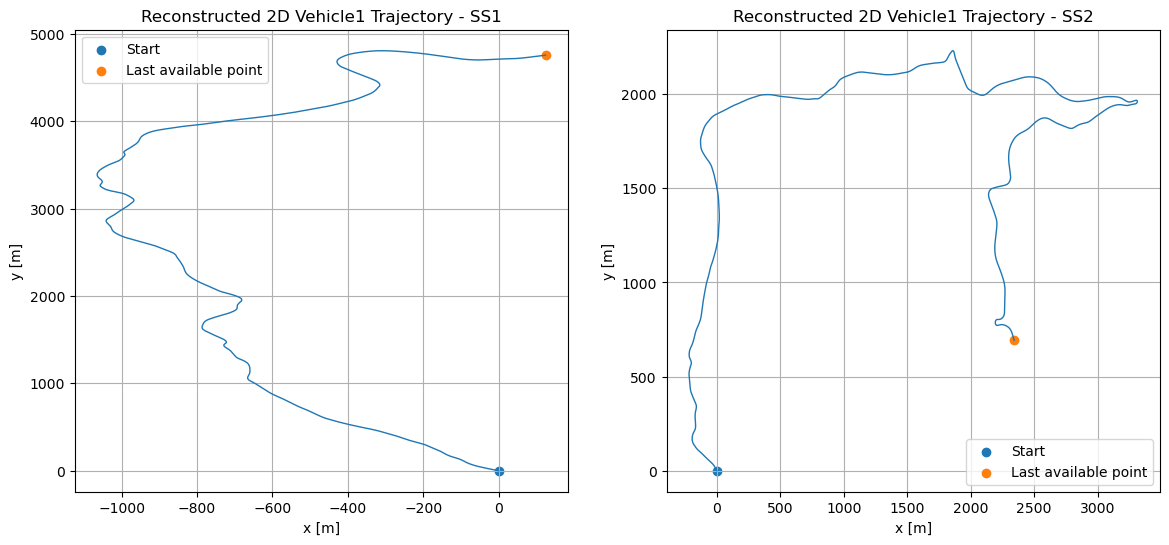

In [338]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(ss1["x"], ss1["y"], linewidth = 1)

plt.scatter(ss1["x"].iloc[0], ss1["y"].iloc[0], marker = "o", label = "Start")
last_valid = ss1[["x", "y"]].dropna().iloc[-1]
plt.scatter(last_valid["x"], last_valid["y"], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS1")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ss2["x"], ss2["y"], linewidth = 1)

plt.scatter(ss2["x"].iloc[0], ss2["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss2["x"].iloc[-1], ss2["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS2")
plt.grid()
plt.legend()

plt.show()


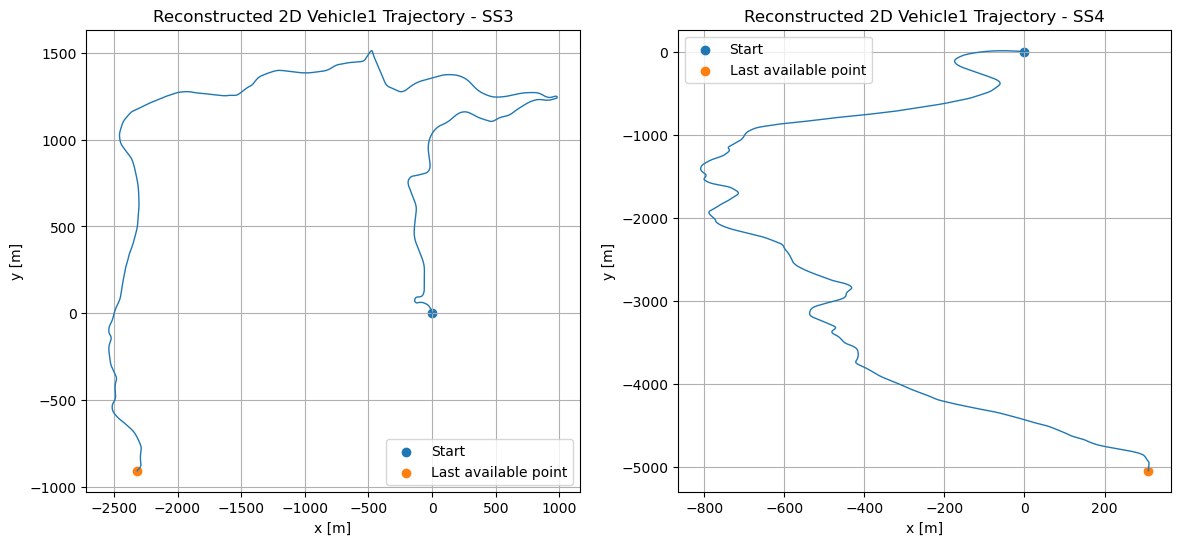

In [339]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(ss3["x"], ss3["y"], linewidth = 1)

plt.scatter(ss3["x"].iloc[0], ss3["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss3["x"].iloc[-1], ss3["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS3")
plt.grid()
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(ss4["x"], ss4["y"], linewidth = 1)

plt.scatter(ss4["x"].iloc[0], ss4["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss4["x"].iloc[-1], ss4["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS4")
plt.grid()
plt.legend()

plt.show()

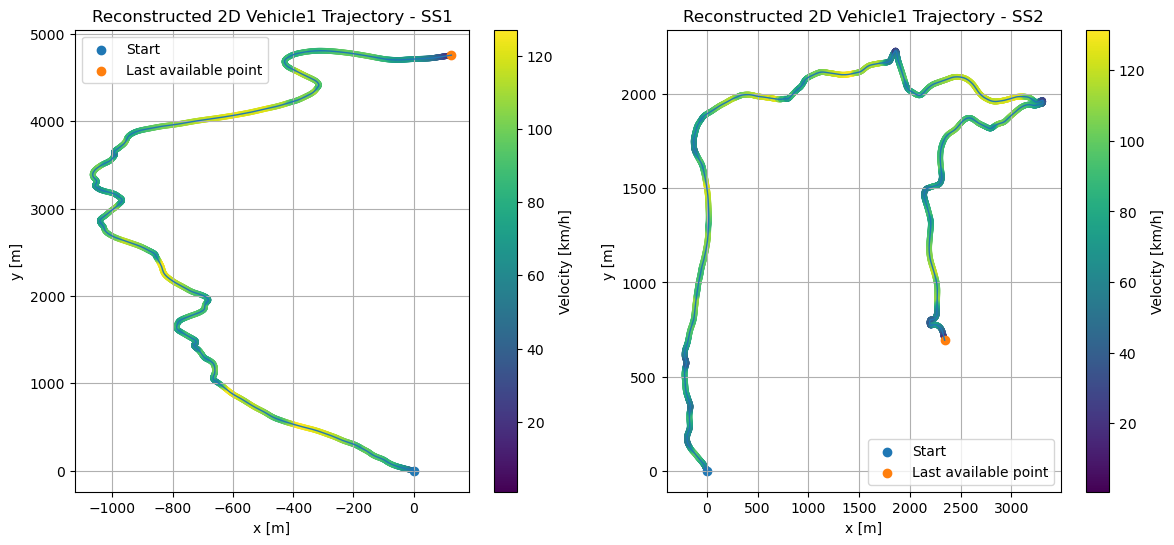

In [340]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(ss1["x"], ss1["y"], linewidth = 1)

scatter = plt.scatter(ss1["x"], ss1["y"], c=ss1["velocity [m/s]"] * 3.6, cmap="viridis", s=10)
plt.colorbar(scatter, label="Velocity [km/h]")
plt.scatter(ss1["x"].iloc[0], ss1["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(last_valid["x"], last_valid["y"], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS1")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ss2["x"], ss2["y"], linewidth = 1)

scatter = plt.scatter(ss2["x"], ss2["y"], c=ss2["velocity [m/s]"] * 3.6, cmap="viridis", s=10)
plt.colorbar(scatter, label="Velocity [km/h]")
plt.scatter(ss2["x"].iloc[0], ss2["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss2["x"].iloc[-1], ss2["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS2")
plt.grid()
plt.legend()


plt.show()

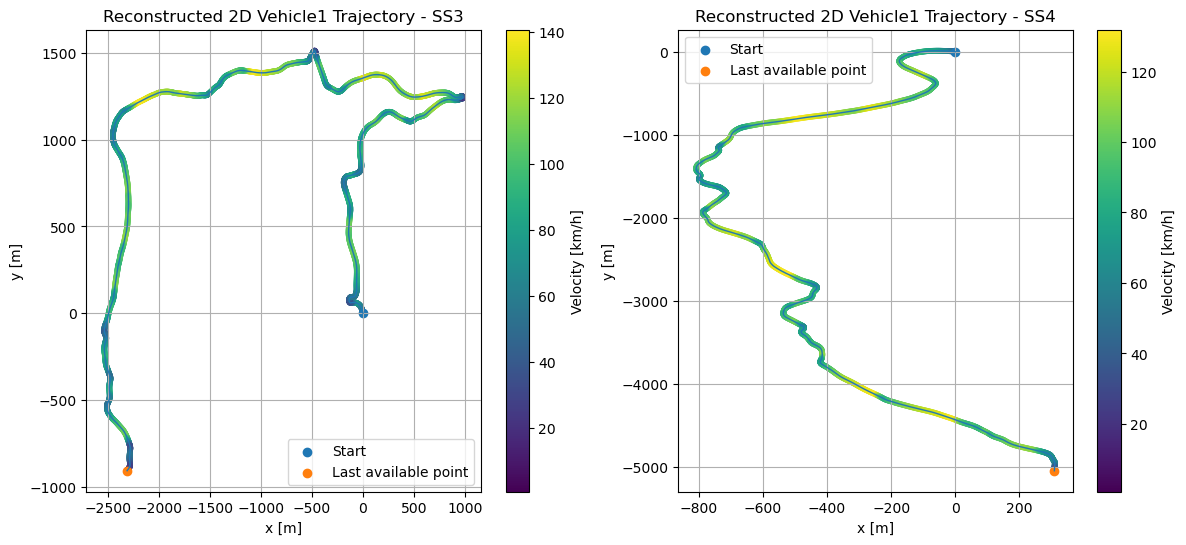

In [341]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
plt.plot(ss3["x"], ss3["y"], linewidth = 1)

scatter = plt.scatter(ss3["x"], ss3["y"], c=ss3["velocity [m/s]"] * 3.6, cmap="viridis", s=10)
plt.colorbar(scatter, label="Velocity [km/h]")
plt.scatter(ss3["x"].iloc[0], ss3["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss3["x"].iloc[-1], ss3["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS3")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ss4["x"], ss4["y"], linewidth = 1)

scatter = plt.scatter(ss4["x"], ss4["y"], c=ss4["velocity [m/s]"] * 3.6, cmap="viridis", s=10)
plt.colorbar(scatter, label="Velocity [km/h]")
plt.scatter(ss4["x"].iloc[0], ss4["y"].iloc[0], marker = "o", label = "Start")
plt.scatter(ss4["x"].iloc[-1], ss4["y"].iloc[-1], marker = "o", label = "Last available point")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt. title("Reconstructed 2D Vehicle1 Trajectory - SS4")
plt.grid()
plt.legend()


plt.show()